In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = "/content/drive/MyDrive/Praktikum//praktikum07/Data/"

In [3]:
import pandas as pd

df = pd.read_csv(path + 'apples_and_oranges.csv')

df.head()

,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange


In [12]:
#buat ngeliat 5 data pertama
print("Beberapa baris pertama dari dataset:")
display(df.head())

#ngecek info umum dataset nya
print("\nInformasi dataset:")
df.info()

#buat cek apakah ada missing value
print("\nJumlah nilai yang hilang di setiap kolom:")
print(df.isnull().sum())

Beberapa baris pertama dari dataset:


,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange



Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  40 non-null     int64  
 1   Size    40 non-null     float64
 2   Class   40 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB

Jumlah nilai yang hilang di setiap kolom:
Weight    0
Size      0
Class     0
dtype: int64


In [14]:
#buat cek nama nama kolom dalam dataset
print(df.columns)


Index(['Weight', 'Size', 'Class'], dtype='object')


In [18]:
X = df.drop('Class', axis=1)
y = df['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler

#normalisasi fitur numerik biar skala datanya seragam
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
from sklearn.svm import SVC

model = SVC(kernel='rbf')
model.fit(X_train_scaled, y_train)


SVC()

Akurasi: 1.0

Laporan Klasifikasi:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00         6
      orange       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12


Confusion Matrix:
[[6 0]
 [0 6]]


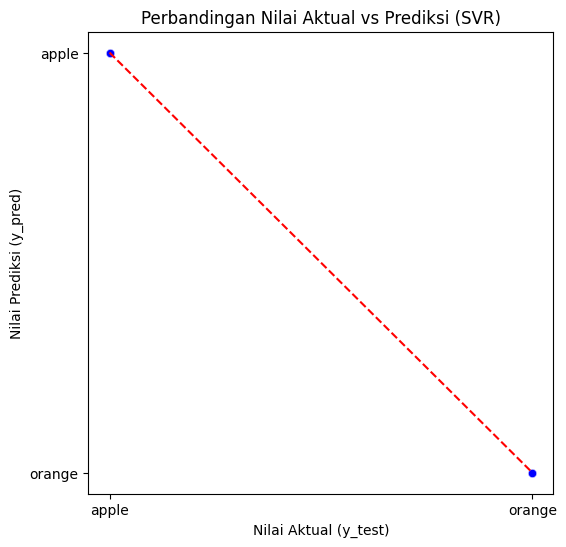

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#prediksi
y_pred = model.predict(X_test_scaled)

#evaluasi
acc = accuracy_score(y_test, y_pred)
print("Akurasi:", acc)

print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


#visualisasi hasil prediksi
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # garis ideal
plt.xlabel("Nilai Aktual (y_test)")
plt.ylabel("Nilai Prediksi (y_pred)")
plt.title("Perbandingan Nilai Aktual vs Prediksi (SVR)")
plt.show()
